<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-16-Gradient_Boosting_(From_Scratch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd

In [6]:
# generating data set
np.random.seed(42)
x= np.random.rand(100,1)-0.5
y=3*x[:,0]**2 + 0.05*np.random.randn(100) # y=3x^2 + c

In [7]:
df = pd.DataFrame()

In [8]:
df['x']=x.reshape(100)
df['y']=y

In [9]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


Text(0.5, 1.0, 'x vs y')

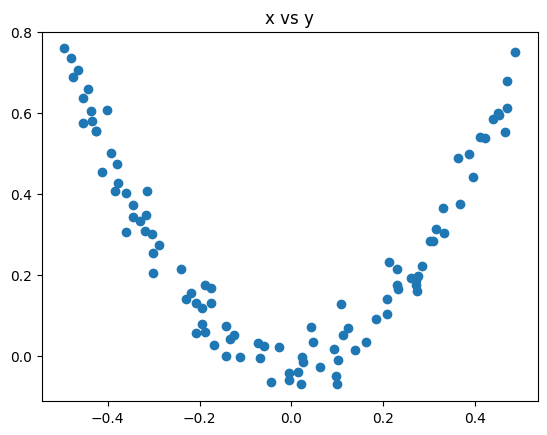

In [11]:
# plotting
import matplotlib.pyplot as plt
plt.scatter(df['x'],df['y'])
plt.title('x vs y')

In [12]:
# making first prediction , ie (prediction of model 1)
# ie mean of all value of y column
df['pred1']= df['y'].mean()

In [15]:
# now calculating error ie called pseudo residual in gradient boosting
# pseudo residual = actual - prediction
# pseudo means - fake
# called pseudo because , actual residual is calculated in regression model ie-
# residial = (actual - prediction)^2
df['res1']=df['y']-df['pred1']


In [16]:
df

,x,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


Text(0.5, 1.0, 'x vs y')

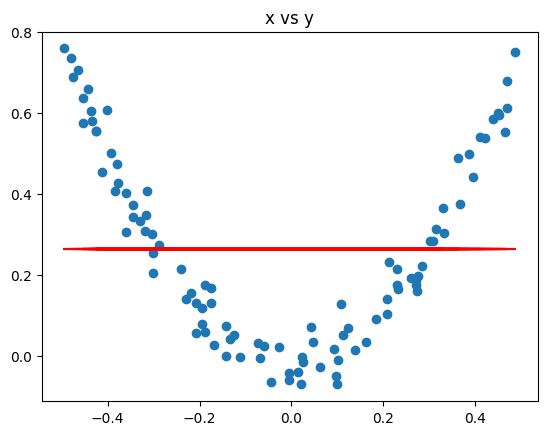

In [19]:
# plotting
plt.scatter(df['x'],df['y'])
plt.plot(df['x'],df['pred1'],color='red')
plt.title('x vs y')

In [26]:
# import model
from sklearn.tree import DecisionTreeRegressor
tree1 = DecisionTreeRegressor(max_leaf_nodes =8)

In [27]:
tree1.fit(df['x'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

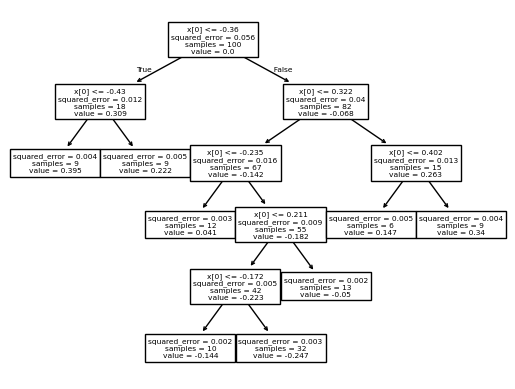

In [29]:
# plotting tree
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [45]:
# generating x_test data
x_test = np.linspace(-0.5,0.5,500)

In [46]:
y_pred = 0.265458 + tree1.predict(x_test.reshape(500,1))

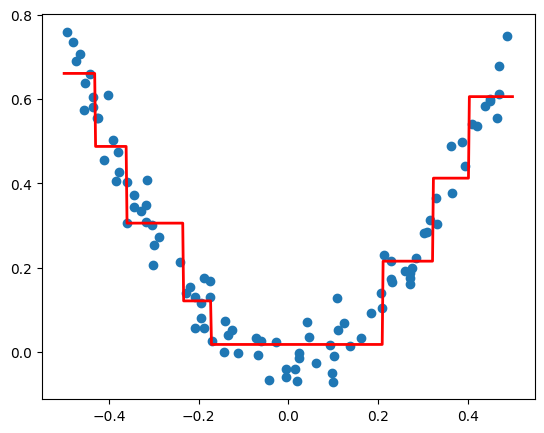

In [49]:
# plotting
plt.figure(figsize=(14,5))
plt.subplot(121)
plt.plot(x_test,y_pred,linewidth = 2, color="red")
plt.scatter(df['x'],df['y'])

In [56]:
# adding pred 2 in data frame
df['pred2']= 0.265458 + tree1.predict(df['x'].values.reshape(100,1))

In [57]:
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [58]:
# calculating residual 2
df['res2']= df['y'] - df['pred2']

In [59]:
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,0.018319,-0.058994
96,0.022733,-0.002305,0.265458,-0.267763,0.018319,-0.020624
97,-0.072459,0.032809,0.265458,-0.232650,0.018319,0.014489
98,-0.474581,0.689516,0.265458,0.424057,0.660912,0.028604


In [62]:
tree2 = DecisionTreeRegressor(max_leaf_nodes =8)

In [64]:
tree2.fit(df['x'].values.reshape(100,1),df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [65]:
y_pred = 0.265458 + sum(regressor.predict(x_test.reshape(-1,1))for regressor in [tree1,tree2])

Text(0.5, 1.0, 'x vs y')

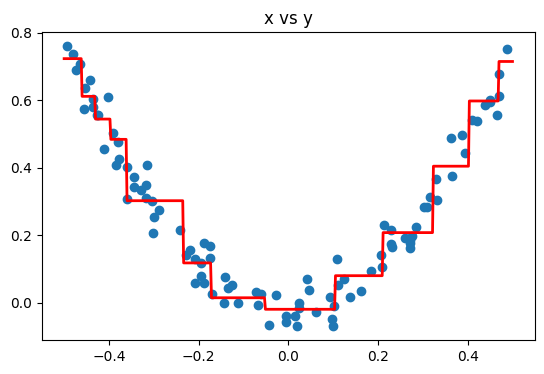

In [66]:
plt.figure(figsize = (14,4))
plt.subplot(121)
plt.plot(x_test,y_pred,linewidth=2,color='red')
plt.scatter(df['x'],df['y'])
plt.title('x vs y')

In [72]:
# now instead of making multiple model making a function that takes input ,
# that how many numbers of models must be made

def gradient_boost(x,y,number,lr , count=1, regs=[],foo=None):
  if number ==0:
    return
  else:
    # do gradient boosting
    if count > 1:
      y= y - regs[-1].predict(x)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth =5,random_state=42)
    tree_reg.fit(x,y)
    regs.append(tree_reg)

    x1 = np.linspace(-0.5,0.5,500)
    y_pred = sum(regressor.predict(x1.reshape(-1,1))for regressor in regs)

    print(number)
    plt.figure(figsize = (14,4))
    plt.plot(x1,y_pred,linewidth=2)
    plt.plot(x[:,0],foo,"r.")
    plt.show()

    gradient_boost(x,y,number-1,lr,count+1,regs,foo)


5


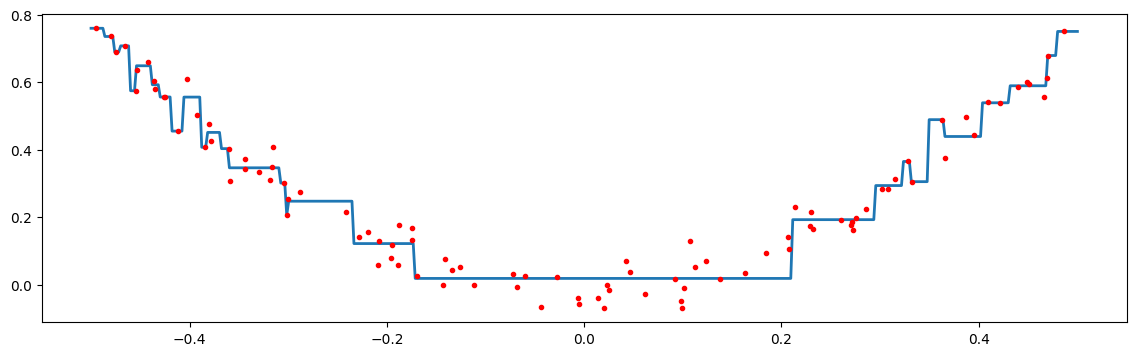

4


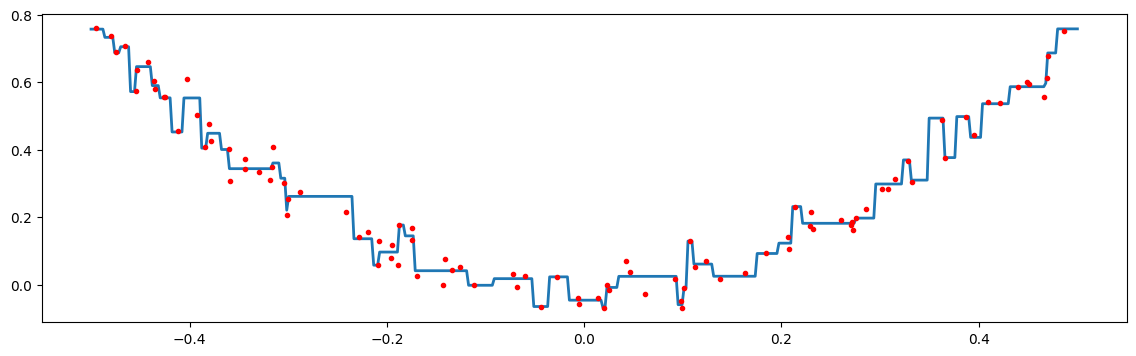

3


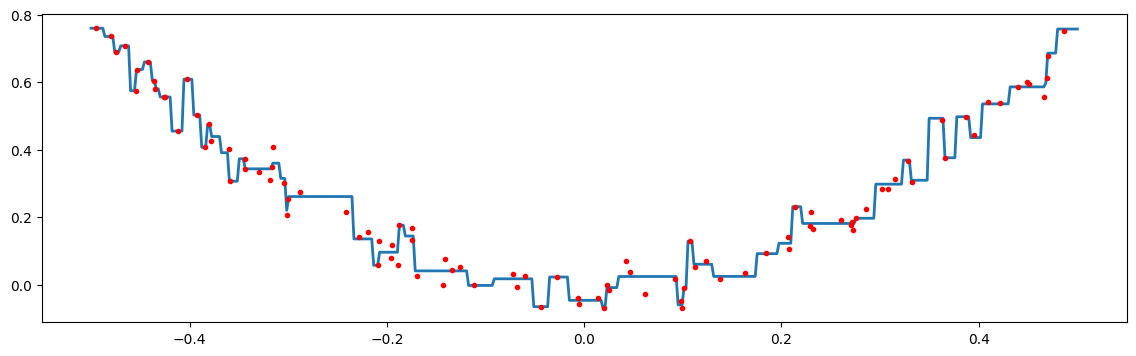

2


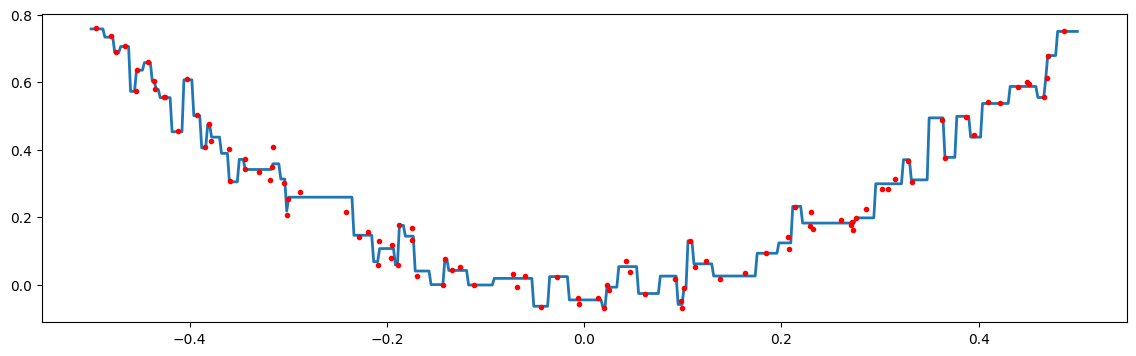

1


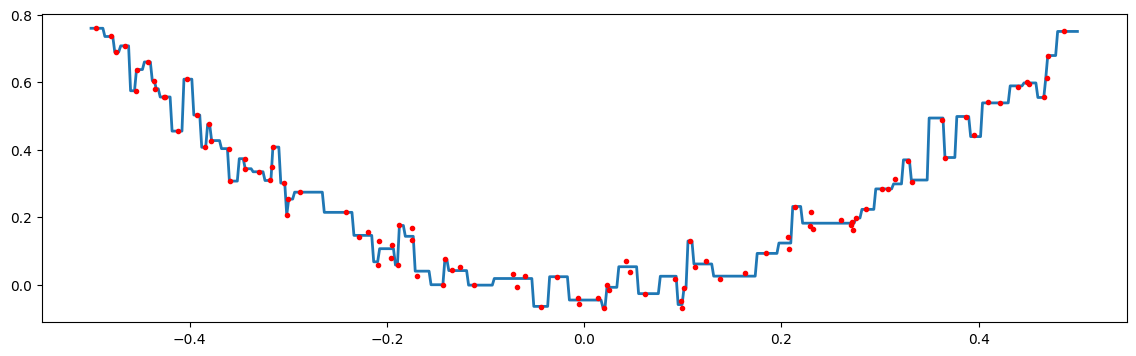

In [73]:
np.random.seed(42)
x = np.random.rand(100,1) - 0.5
y = 3*x[:,0]**2 + 0.05 * np.random.randn(100)
gradient_boost(x,y,5,lr=1)